In [1]:
import torch
import matplotlib.pyplot as plt

from src.dimension_reduction.convex_simplex_structured_matrix_factorization import ConvexSimplexStructuredMatrixFactorizationSolver

# torch.manual_seed(0)

Data shape: torch.Size([2000, 3])


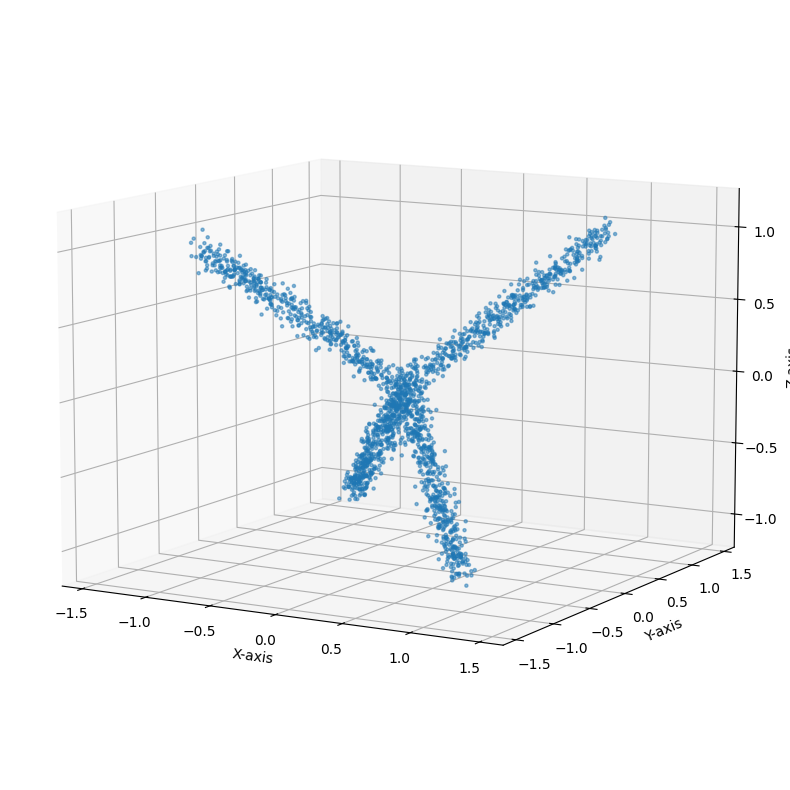

In [2]:
# construct data set from the four corners of a tetrahedron in R3
# construct tetrahedron corners
data_clusters = torch.tensor([[1.0, 1.0, 1.0],
                              [1.0, -1.0, -1.0],
                              [-1.0, 1.0, -1.0],
                              [-1.0, -1.0, 1.0]])

# generate data 
num_data_per_cluster = 500
sigma = 0.05
data = []
for center in data_clusters:
    for _ in range(num_data_per_cluster):
        t = torch.rand(1)
        point = t * center + (1 - t) * torch.zeros(3)
        point += sigma * torch.randn(3)  # small Gaussian noise
        data.append(point)
data = torch.stack(data)
print("Data shape:", data.shape)

# plot data in 3D
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(data[:, 0], data[:, 1], data[:, 2], s=5, alpha=0.5)
ax.set_xlabel("X-axis")
ax.set_ylabel("Y-axis")
ax.set_zlabel("Z-axis")
plt.axis('equal')
ax.view_init(elev=10)
plt.tight_layout()
plt.show()

In [3]:
X = data.T  # use the generated data as input
solver = ConvexSimplexStructuredMatrixFactorizationSolver(d=X.shape[0], N=X.shape[1])
solver.fit(X, r=4, n_max=200, max_iter=200)

CSSMF solver finished phase I after 113 iterations with objective value 0.1729 and relative change 0.00
CSSMF solver finished phase II after 6 iterations with objective value 2.5044 and relative change 0.00


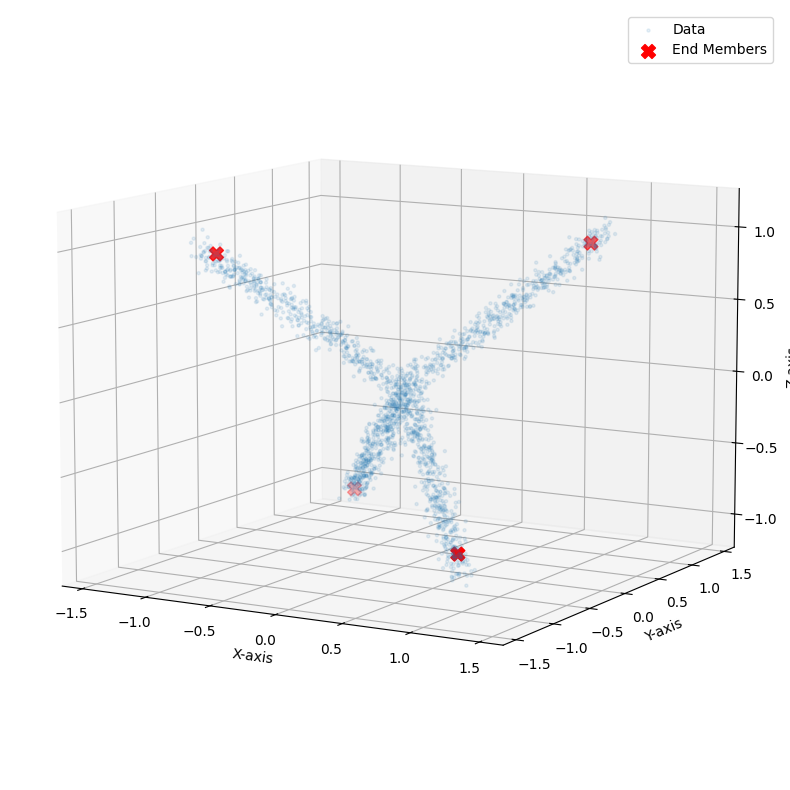

In [4]:
end_members = solver.V.T.cpu().numpy()

# plot
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(data[:, 0], data[:, 1], data[:, 2], s=5, alpha=0.1, label="Data")
ax.scatter(end_members[:, 0], end_members[:, 1], end_members[:, 2], s=100, c='red', marker='X', label="End Members")
ax.set_xlabel("X-axis")
ax.set_ylabel("Y-axis")
ax.set_zlabel("Z-axis")
plt.axis('equal')
ax.view_init(elev=10)
plt.legend()
plt.tight_layout()
plt.show()

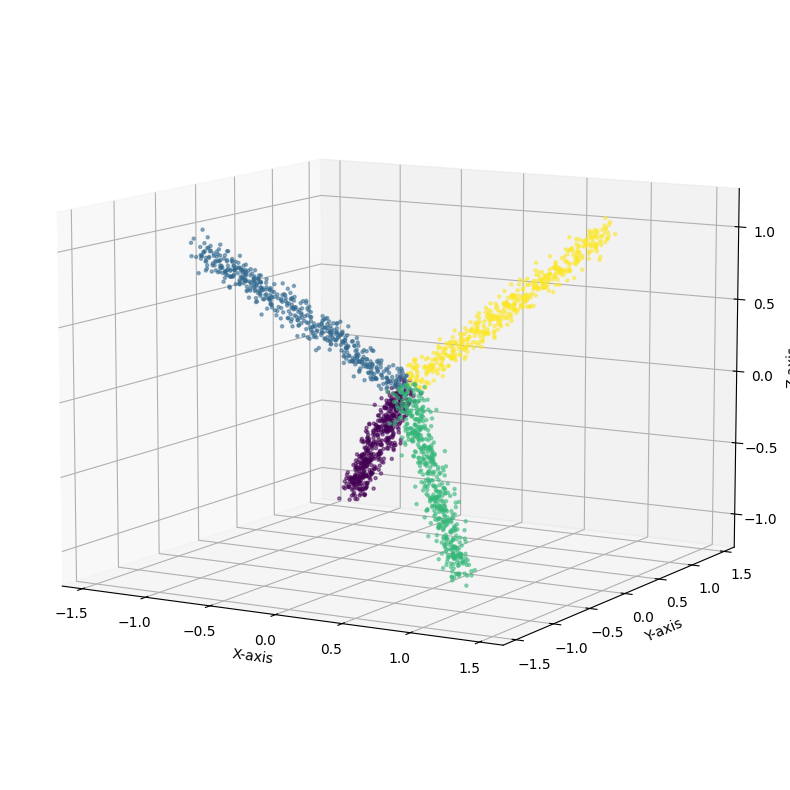

In [5]:
# clustering based on max membership
cluster_assignments = solver.labels.cpu()

# plot clusters
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(data[:, 0], data[:, 1], data[:, 2], s=5, c=cluster_assignments, alpha=0.5)
ax.set_xlabel("X-axis")
ax.set_ylabel("Y-axis")
ax.set_zlabel("Z-axis")
plt.axis('equal')
ax.view_init(elev=10)
plt.tight_layout()
plt.show()